Nicht vergesessen, dass in calc_wav_coh_bvpa_pr noch die ch_list richtig aktiviert gehört.

Handling von negativen Weren in amp: Cedalionfunktion repair_amp (ev. Gio bescheid geben)

In [1]:
### Imports
%matplotlib qt

import importlib
import cedalion
import cedalion.sigproc.bvp_wav_ana_v12
import cedalion.dataclasses.bvp_container
# import numpy as np
# import matplotlib.pyplot as plt

import pandas as pd
import xarray as xr

from cedalion.io.snirf import read_snirf
from cedalion.nirs.cw import int2od
from cedalion.nirs.cw import od2conc

pd.set_option('display.max_rows', 10)
xr.set_options(display_expand_data=False)

def calc_concentratoin(rec):
    od = int2od(rec["amp"])
    dpf = xr.DataArray([6, 6], dims="wavelength", coords={"wavelength" : od.wavelength})
    return od2conc(od, rec.geo3d, dpf)


#### @User: Choose measurement and channel for plots

In [2]:
measurement = '01'
channel_for_plot = 'S4D10'

### Load recording and calculate concentration


In [3]:
### Load recording, clalculate concentration
days =     [ '03',  '05',  '05',  '05',  '06',  '06',  '06',  '06',  '07',  '07',
             '08',  '08',  '08',  '08',  '09',  '09',  '10',  '10',  '11',  '13',
             '13',  '13',  '13',  '13',  '14',  '14']
sessions = ['001', '001', '002', '003', '001', '002', '003', '004', '001', '002',
            '001', '002', '003', '004', '001', '002', '001', '002', '001', '001',
            '002', '003', '004', '005', '001', '002']

m = measurement
d = days[int(m)-1]
s = sessions[int(m)-1]

path_to_snirf_file = (
    f"E:/WorkPy/04_data_mainstudy/Data/measurement_{m}/2025-05-{d}_{s}/2025-05-{d}_{s}_inclAUG.snirf")

recordings = read_snirf(path_to_snirf_file)
rec = recordings[0]
# rec["amp"] = rec["amp"].where(rec["amp"] > 0, np.nan)
rec["conc"] = calc_concentratoin(rec)

In [4]:
# show xarray of concentation time series
rec['conc']

Magnitude,[[[-0.5694810690537886 -0.6095872277571514 -0.6496481526689815 ... -0.07292186855120197 -0.1107893939958408 -0.1639918526873953] [-2.344508715187393 -2.430167097850611 -2.6377734999620897 ... 0.6743890866947507 0.5370666650315683 0.2853010772237874] [-0.6623987987696685 -0.2728983627312602 -0.8226828253654747 ... 0.6897078298526035 -1.1129580235060328 0.27463032859783476] ... [-1.285924158456724 0.9261374911721552 -0.6386202601878195 ... -0.20421276744774555 -1.3416636340847097 -0.9032055460066795] [-0.2882980572270269 -0.3815839256030196 -0.4748853568659514 ... -0.4255051056134753 -0.4974477196841828 -0.5976166689270148] [0.6771144079796988 0.5848746742532543 0.6008807881928586 ... 0.13125462206603372 0.09281007570980339 0.045122377985392405]] [[-0.025454127876366382 -0.030710956530722908 -0.0354657760687306 ... -0.13635972987725448 -0.13720904130168313 -0.14377514064797092] [-0.8935298676873711 -0.875360261558455 -0.9295192260303782 ... 0.149268374645546 0.15374506650723885 0.15672734696168544] [0.28598158188796496 0.3448665568578404 0.6839235054465747 ... -0.9893556593864765 -0.2146900014843097 -0.8417762836583577] ... [1.9735308282160662 -0.7074599858488847 0.7225299119161173 ... -0.2006451889768465 1.454438389422128 0.26337241368247993] [0.441846623069791 0.44608323095404795 0.4355727398433397 ... 0.2315893151203369 0.221247850980125 0.2416697760848061] [2.7924613398189417 2.852024666924249 2.8137763684198376 ... 0.05941432238590294 0.1626935677005651 0.13819614005115866]]]
Units,micromolar


### Creation of Bvp_Container --> BVP extraction --> Waveform: extraction

In [5]:
# for dev
importlib.reload(cedalion.sigproc.bvp_wav_ana_v12)
importlib.reload(cedalion.dataclasses.bvp_container)

<module 'cedalion.dataclasses.bvp_container' from 'E:\\WorkPy\\03_Cedalion\\cedalion\\src\\cedalion\\dataclasses\\bvp_container.py'>

In [6]:
### create BVP_Container
from cedalion.dataclasses.bvp_container import BVP_Container
bvp_cont = BVP_Container()

In [7]:
# show BVP_Container
bvp_cont

BVP Container
  timeseries: ---
  wav_storage_user: ---
  wav_storage_details: ---

In [8]:
### extract BVP time series
from cedalion.sigproc.bvp_wav_ana_v12 import extract_bvp
bvp_ts = extract_bvp(rec["conc"].sel(chromo="HbO"))
bvp_cont['bvp_ts'] = bvp_ts

In [9]:
# show updated BVP_Container and xarray of BVP time series
print(bvp_cont)
display(bvp_cont['bvp_ts'])

BVP Container
  timeseries: ['bvp_ts']
  wav_storage_user: ---
  wav_storage_details: ---


Magnitude,[[[-0.02647393731522079 -0.04313034362986905 -0.05979260484270271 ... -0.1499099311015275 -0.1704715468439988 -0.19361695440320786] [0.0 -0.01617678582917856 -0.03234621662983169 ... 0.449752550415045 0.42891147351739345 0.4054892163663933] [0.02647393731522079 0.026953557800690482 0.02744638821287102 ... 0.5996624815165725 0.5993830203613922 0.5991061707696012]] [[-0.022014946558902376 -0.04807993929816841 -0.0922765621297001 ... -0.4780276324399897 -0.5747496760845539 -0.691242191899176] [0.0 -0.022326367774369346 -0.06275081529472594 ... 2.8438915024780465 2.7467274437473876 2.6298097924111805] [0.022014946558902376 0.025753571523799063 0.029525746834974165 ... 3.321919134918036 3.3214771198319415 3.3210519843103565]] [[-0.42756120044210427 -0.16529465293383694 -0.05029504593477796 ... -0.9183835389988195 -0.4936822450070069 0.43561144120151174] [0.0 0.2622871074860223 0.3773273116357662 ... -0.4048367751636502 0.013832348593818815 0.9370291273675031] [0.42756120044210427 0.42758176041985924 0.4276223575705442 ... 0.5135467638351693 0.5075145936008257 0.5014176861659914]] ... [[-1.3278458627891387 0.05116515332570204 0.794063056739343 ... -0.7740636924870367 -0.6734395232808188 -0.3404293267279667] [0.0 1.3777481942390855 2.119394602254186 ... -0.04987103236493999 0.050229378761829556 0.3827186124500446] [1.3278458627891387 1.3265830409133834 1.325331545514843 ... 0.7241926601220967 0.7236689020426483 0.7231479391780113]] [[0.055913571278625784 0.013951920406435045 -0.02796761460418401 ... -0.2919146440358721 -0.33286681547265107 -0.378563920682871] [0.0 -0.037612243528917136 -0.07522701724453544 ... -0.22604520728629476 -0.2653084869738472 -0.309318611699988] [-0.055913571278625784 -0.05156416393535218 -0.04725940264035143 ... 0.0658694367495773 0.06755832849880386 0.069245308982883]] [[0.15603355919342765 0.09848423050844146 0.061151241969082004 ... -0.30903519237624816 -0.3348693085684875 -0.36227817426539893] [0.0 -0.053914356692353706 -0.08763167436410876 ... -0.5927515150862473 -0.6116034877923882 -0.6319920299943064] [-0.15603355919342765 -0.15239858720079516 -0.14878291633319077 ... -0.2837163227099992 -0.27673417922390064 -0.26971385572890744]]]
Units,micromolar


In [10]:
### extract waveforms
from cedalion.sigproc.bvp_wav_ana_v12 import extract_waveforms
wav_storage_user, wav_storage_details = extract_waveforms(bvp_ts.sel(compound="bvp_ts"))
bvp_cont.wav_storage_user = wav_storage_user
bvp_cont.wav_storage_details = wav_storage_details

In [11]:
# show updated BVP_Container
print(bvp_cont)

BVP Container
  timeseries: ['bvp_ts']
  wav_storage_user: ['bvp_max_value', 'bvp_max_idx', 'bvp_min_value', 'bvp_min_idx']
  wav_storage_details: ['list_wav_raw_and_y_normal', 'nparray_wav_xy_normal_all', 'nparray_wav_xy_normal_zscore_all']


Plots

In [12]:
# plot [HbO] and BVP time series
from cedalion.sigproc.bvp_wav_ana_v12 import plot_concts_bvpts
plot_concts_bvpts(bvp_cont, channel_for_plot)

E:\WorkPy\03_Cedalion\cedalion\src\cedalion\sigproc\bvp_wav_ana_v12.py:1439: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


In [13]:
# plot waveforms
from cedalion.sigproc.bvp_wav_ana_v12 import plot_wavs_4x
plot_wavs_4x(bvp_cont, channel_for_plot)

### Waveforms: artefact removal

In [14]:
# for dev
importlib.reload(cedalion.sigproc.bvp_wav_ana_v12)

<module 'cedalion.sigproc.bvp_wav_ana_v12' from 'E:\\WorkPy\\03_Cedalion\\cedalion\\src\\cedalion\\sigproc\\bvp_wav_ana_v12.py'>

In [15]:
### remove artifact waveforms
from cedalion.sigproc.bvp_wav_ana_v12 import remove_artifact_waveforms
bvp_cont.wav_storage_user, bvp_cont.wav_storage_details = remove_artifact_waveforms(
    bvp_cont['bvp_ts'],
    bvp_cont.wav_storage_user,
    bvp_cont.wav_storage_details)

In [16]:
# show updated BVP_Container
print(bvp_cont)

BVP Container
  timeseries: ['bvp_ts']
  wav_storage_user: ['bvp_max_value', 'bvp_max_idx', 'bvp_min_value', 'bvp_min_idx', 'nparray_wav_xy_normal_zscore_all_woa', 'nparray_wav_xy_normal_all_woa']
  wav_storage_details: ['list_wav_raw_and_y_normal', 'nparray_wav_xy_normal_all', 'nparray_wav_xy_normal_zscore_all', 'P_975', 'bvp_wav_dev']


Plot

In [17]:
# plot waveforms without artefacts
from cedalion.sigproc.bvp_wav_ana_v12 import plot_wavs_woa
plot_wavs_woa(bvp_cont, channel_for_plot)

### Waveforms: classification

In [18]:
# for dev
importlib.reload(cedalion.sigproc.bvp_wav_ana_v12)

<module 'cedalion.sigproc.bvp_wav_ana_v12' from 'E:\\WorkPy\\03_Cedalion\\cedalion\\src\\cedalion\\sigproc\\bvp_wav_ana_v12.py'>

In [19]:
### classify waveforms using the metrices 'delta' and 'max'
from cedalion.sigproc.bvp_wav_ana_v12 import classify_waveforms
bvp_cont.wav_storage_user, bvp_cont.wav_storage_details = classify_waveforms(
    bvp_cont, 'delta')
bvp_cont.wav_storage_user, bvp_cont.wav_storage_details = classify_waveforms(
    bvp_cont, 'max')

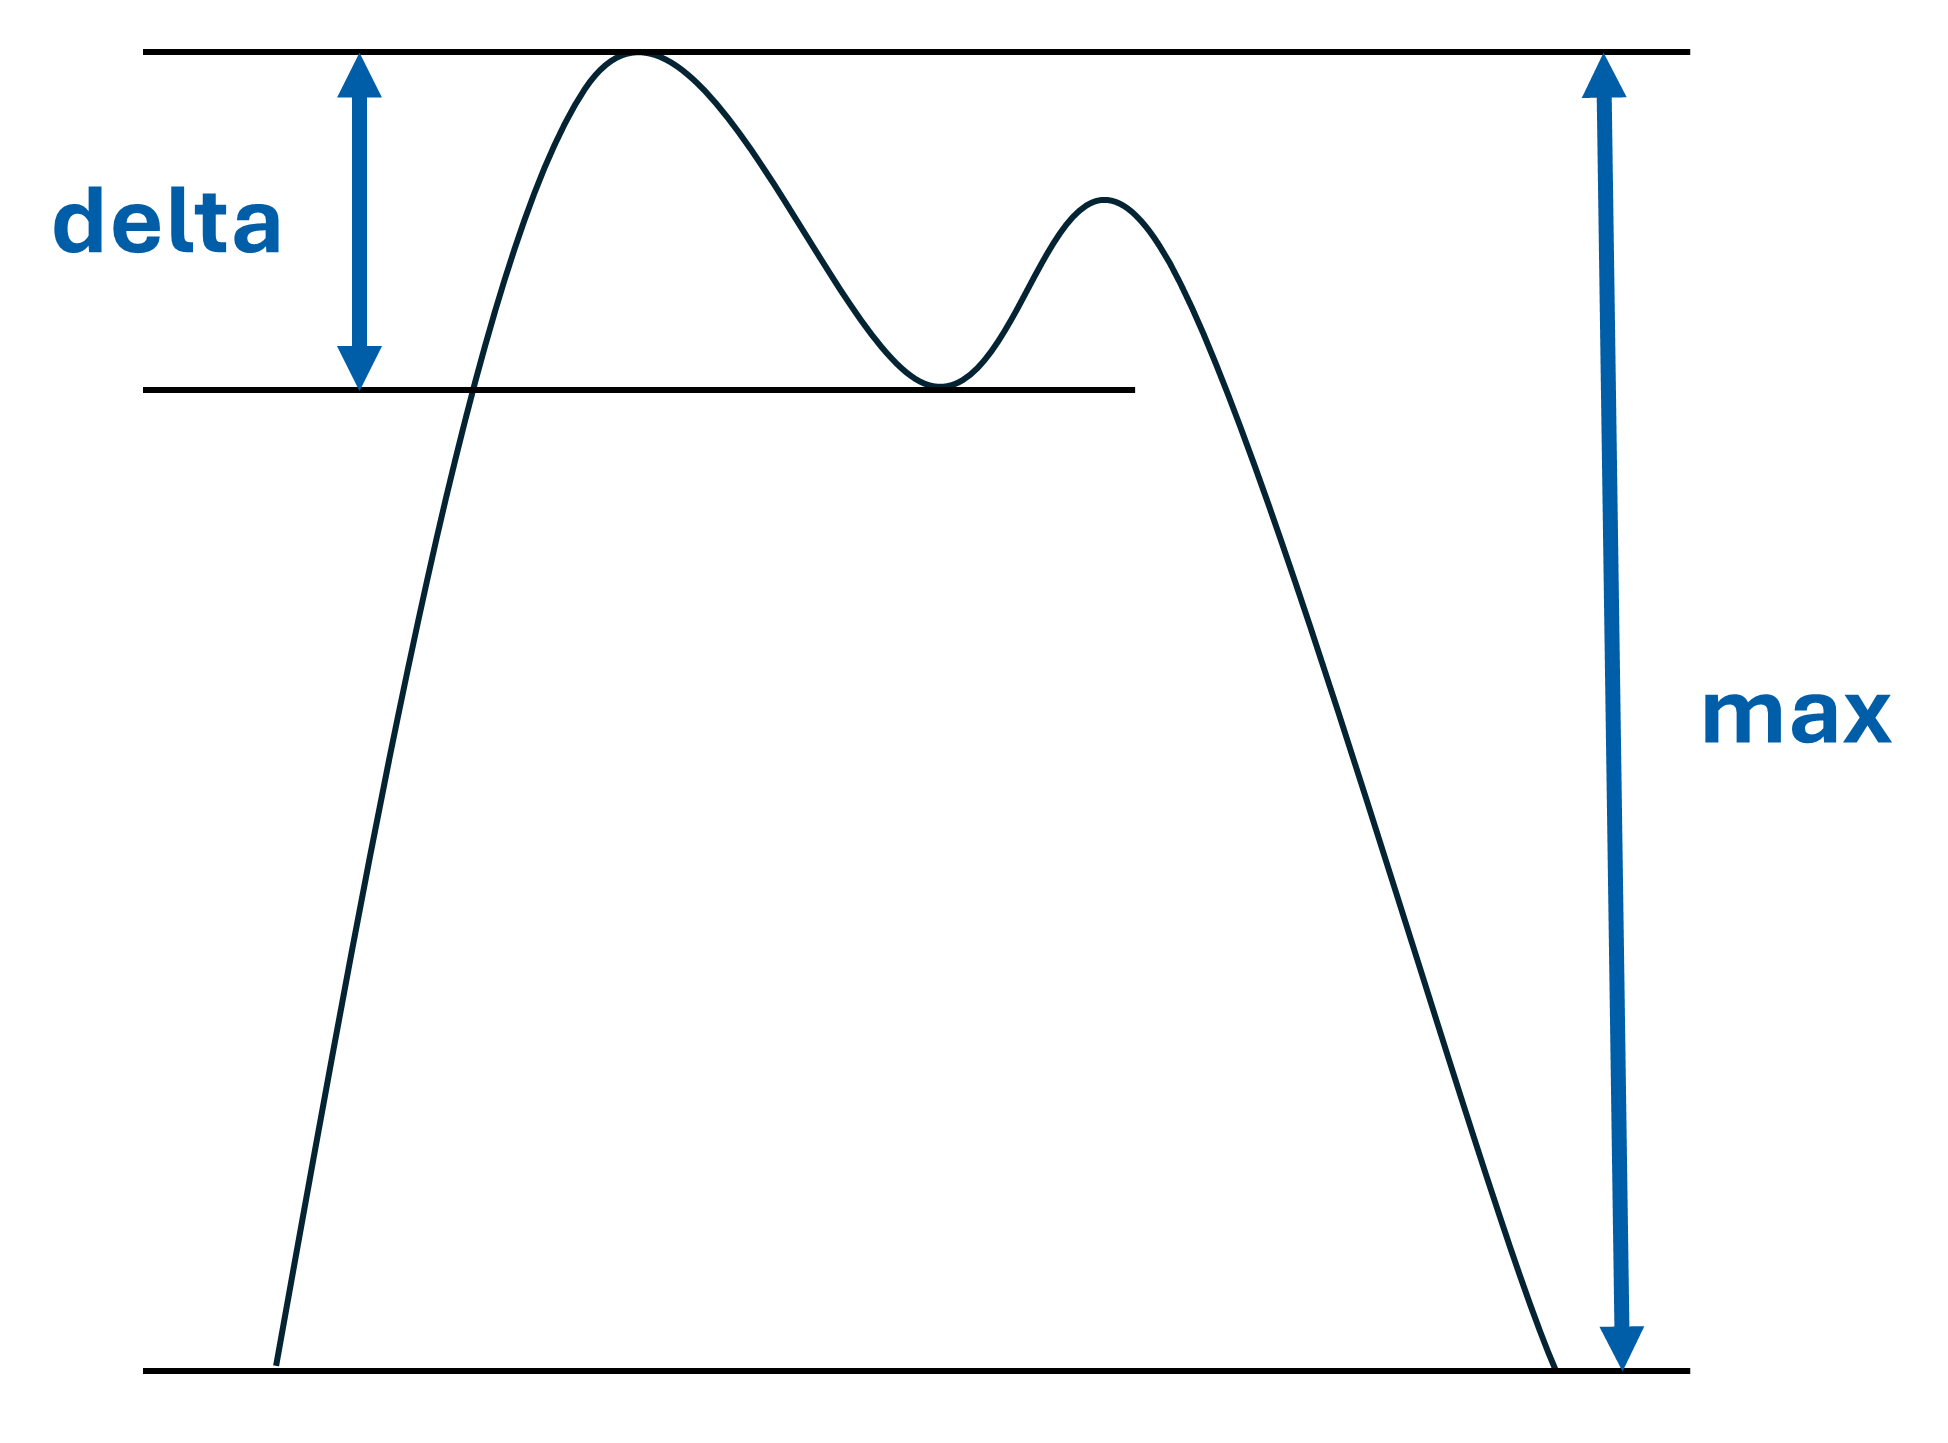

In [20]:
# show number of waveforms for each channel which have a delta of 0
for ch in bvp_cont['bvp_ts'].channel.values:
    print(wav_storage_details[ch]["text_num_del_wavs"])

S1D15:  34  of  594
S1D16:  13  of  594
S2D1:  7  of  587
S2D2:  4  of  595
S2D14:  25  of  594
S2D15:  5  of  595
S2D17:  6  of  592
S3D1:  39  of  594
S3D2:  53  of  594
S3D14:  62  of  594
S3D15:  79  of  584
S4D1:  0  of  514
S4D5:  1  of  595
S4D10:  18  of  594
S4D15:  25  of  594
S4D18:  19  of  594
S5D1:  7  of  594
S5D5:  29  of  594
S5D10:  18  of  595
S5D15:  23  of  592
S6D2:  100  of  594
S6D14:  48  of  595
S7D5:  24  of  594
S7D10:  23  of  594
S8D19:  4  of  594
S9D3:  64  of  594
S9D9:  73  of  594
S10D3:  2  of  594
S10D9:  19  of  594
S10D20:  20  of  594
S11D6:  37  of  594
S11D13:  2  of  595
S11D21:  42  of  594
S12D6:  23  of  594
S12D13:  11  of  594
S13D8:  5  of  546
S14D8:  4  of  540
S14D11:  108  of  594
S14D12:  223  of  589
S15D7:  56  of  594
S15D8:  7  of  545
S15D11:  416  of  594
S15D22:  15  of  594
S16D4:  49  of  594
S16D8:  5  of  557
S16D12:  106  of  594
S16D23:  13  of  590


In [21]:
# show updated BVP_Container
print(bvp_cont)

BVP Container
  timeseries: ['bvp_ts']
  wav_storage_user: ['bvp_max_value', 'bvp_max_idx', 'bvp_min_value', 'bvp_min_idx', 'nparray_wav_xy_normal_zscore_all_woa', 'nparray_wav_xy_normal_all_woa', 'nparray_wav_delta_type1', 'nparray_wav_delta_type2', 'nparray_wav_delta_type3', 'nparray_wav_max_type1', 'nparray_wav_max_type2', 'nparray_wav_max_type3']
  wav_storage_details: ['list_wav_raw_and_y_normal', 'nparray_wav_xy_normal_all', 'nparray_wav_xy_normal_zscore_all', 'P_975', 'bvp_wav_dev', 'delta_bvp_wav', 'delta_P_25', 'delta_P_75', 'text_num_del_wavs', 'max_bvp_wav', 'max_P_25', 'max_P_75']


#### @User: choose classification metric for plot

In [22]:
classfication_metric = 'max' # 'max' or 'delta'

In [23]:
# plot classified waveforms
from cedalion.sigproc.bvp_wav_ana_v12 import plot_wavs_classes
plot_wavs_classes(bvp_cont, channel_for_plot, classfication_metric)

### BVPA extraction

In [24]:
# for dev
importlib.reload(cedalion.sigproc.bvp_wav_ana_v12)

<module 'cedalion.sigproc.bvp_wav_ana_v12' from 'E:\\WorkPy\\03_Cedalion\\cedalion\\src\\cedalion\\sigproc\\bvp_wav_ana_v12.py'>

In [25]:
### extract BVPA
from cedalion.sigproc.bvp_wav_ana_v12 import extract_bvpa
bvpa_ts = extract_bvpa(
    bvp_cont['bvp_ts'].sel(compound="bvp_ts"),
    bvp_cont.wav_storage_user
)
bvp_cont['bvpa_ts'] = bvpa_ts

In [26]:
# show updated BVP_Container and xarray of BVPA time series
print(bvp_cont)
display(bvp_cont['bvpa_ts'])

BVP Container
  timeseries: ['bvp_ts', 'bvpa_ts']
  wav_storage_user: ['bvp_max_value', 'bvp_max_idx', 'bvp_min_value', 'bvp_min_idx', 'nparray_wav_xy_normal_zscore_all_woa', 'nparray_wav_xy_normal_all_woa', 'nparray_wav_delta_type1', 'nparray_wav_delta_type2', 'nparray_wav_delta_type3', 'nparray_wav_max_type1', 'nparray_wav_max_type2', 'nparray_wav_max_type3']
  wav_storage_details: ['list_wav_raw_and_y_normal', 'nparray_wav_xy_normal_all', 'nparray_wav_xy_normal_zscore_all', 'P_975', 'bvp_wav_dev', 'delta_bvp_wav', 'delta_P_25', 'delta_P_75', 'text_num_del_wavs', 'max_bvp_wav', 'max_P_25', 'max_P_75']


Magnitude,[[[0.20223690397356525 0.20223690397356525 0.20223690397356525 ... 0.23074004946692345 0.23094106977757012 0.23112483698971262] [-0.17481574556178778 -0.17481574556178778 -0.17481574556178778 ... -0.2905475283869285 -0.2903728496729523 -0.2901925690656781] [0.377052649535353 0.377052649535353 0.377052649535353 ... 0.5212875778538519 0.5213139194505224 0.5213174060553907] [0.3741564579787802 0.3746265590166682 0.3751212975072269 ... 0.5213317722214975 0.5213890490235819 0.5214280947748592]] [[0.6541792881197659 0.6541792881197659 0.6541792881197659 ... 0.8986249403905792 0.9000067796495442 0.9013290182221378] [-0.6164779901925322 -0.6164779901925322 -0.6164779901925322 ... -1.0451529663140842 -1.0465008523346848 -1.0478270450079137] [1.270657278312298 1.270657278312298 1.270657278312298 ... 1.9437779067046632 1.946507631984229 1.9491560632300515] [1.2627312247341915 1.2639124273928761 1.265185446031526 ... 1.9440094239772063 1.9469012068845781 1.9497359188043681]] [[1.0095269787976575 1.0095269787976575 1.0095269787976575 ... 0.9846124554269498 0.9760591296566012 0.9674271963078173] [-0.5874871338765716 -0.5874871338765716 -0.5874871338765716 ... -0.9183835389988195 -0.8879390058923634 -0.8568744755706943] [1.5970141126742292 1.5970141126742292 1.5970141126742292 ... 1.9029959944257693 1.8639981355489645 1.8243016718785117] [1.5608697571368395 1.5695914554713315 1.5778887109778506 ... 1.9028202902530555 1.8636994418424135 1.823861605170489]] ... [[1.3048120757669432 1.3048120757669432 1.3048120757669432 ... 4.931132019860507 5.302550566950371 5.693687518442834] [-1.5722991091155807 -1.5722991091155807 -1.5722991091155807 ... -0.7740636924870367 -0.7694567621476014 -0.7648671058559809] [2.8771111848825237 2.8771111848825237 2.8771111848825237 ... 5.705195712347543 6.072007329097973 6.458554624298815] [2.900203807430505 2.899086355771026 2.89672030411708 ... 5.638735248135408 5.9590254950530905 6.292097758380199]] [[0.3189375937212592 0.3189375937212592 0.3189375937212592 ... 0.3829854980178504 0.38384604226158764 0.3847063770497546] [-0.24354069194120848 -0.24354069194120848 -0.24354069194120848 ... -0.38112312619814204 -0.37905738318060844 -0.37695239798008356] [0.5624782856624677 0.5624782856624677 0.5624782856624677 ... 0.7641086242159925 0.762903425442196 0.7616587750298381] [0.5584456017203577 0.5582423587009402 0.5583385435907636 ... 0.7641618252784117 0.7629938662227482 0.7617920218164148]] [[0.3681246522226035 0.3681246522226035 0.3681246522226035 ... 0.5984742642887068 0.6014800618198319 0.6044885233362524] [-0.10853767466275899 -0.10853767466275899 -0.10853767466275899 ... -0.4184147907558704 -0.4200243947164201 -0.42166618969377107] [0.4766623268853625 0.4766623268853625 0.4766623268853625 ... 1.0168890550445773 1.021504456536252 1.0261547130300235] [0.4701812028269548 0.4704742217864258 0.4710640955146473 ... 1.0168579052240077 1.0214515024417614 1.0260766955374294]]]
Units,micromolar


Plot

In [27]:
# plot BVP and BVPA time series
from cedalion.sigproc.bvp_wav_ana_v12 import plot_bvpts_bvpats
plot_bvpts_bvpats(bvp_cont, channel_for_plot)

### Pulse Rate: extraction

In [28]:
# for dev
importlib.reload(cedalion.sigproc.bvp_wav_ana_v12)

<module 'cedalion.sigproc.bvp_wav_ana_v12' from 'E:\\WorkPy\\03_Cedalion\\cedalion\\src\\cedalion\\sigproc\\bvp_wav_ana_v12.py'>

In [29]:
### extract pulse rate
from cedalion.sigproc.bvp_wav_ana_v12 import extract_pulse_rate
pulse_rate_ts = extract_pulse_rate(
    bvp_cont['bvp_ts'].sel(compound="bvp_ts"),
    bvp_cont.wav_storage_user
)
bvp_cont['pulse_rate_ts'] = pulse_rate_ts

In [30]:
# show updated BVP_Container and xarray of pulse rate time series
print(bvp_cont)
display(bvp_cont['pulse_rate_ts'])

BVP Container
  timeseries: ['bvp_ts', 'bvpa_ts', 'pulse_rate_ts']
  wav_storage_user: ['bvp_max_value', 'bvp_max_idx', 'bvp_min_value', 'bvp_min_idx', 'nparray_wav_xy_normal_zscore_all_woa', 'nparray_wav_xy_normal_all_woa', 'nparray_wav_delta_type1', 'nparray_wav_delta_type2', 'nparray_wav_delta_type3', 'nparray_wav_max_type1', 'nparray_wav_max_type2', 'nparray_wav_max_type3']
  wav_storage_details: ['list_wav_raw_and_y_normal', 'nparray_wav_xy_normal_all', 'nparray_wav_xy_normal_zscore_all', 'P_975', 'bvp_wav_dev', 'delta_bvp_wav', 'delta_P_25', 'delta_P_75', 'text_num_del_wavs', 'max_bvp_wav', 'max_P_25', 'max_P_75']


Magnitude,[[[60.001840117767536 60.001840117767536 60.001840117767536 ... 54.54712737978866 54.54712737978866 54.54712737978866] [55.83046653602935 55.99190729481206 56.153037993570415 ... 54.319423266984 54.31666544397683 54.314202060526384]] [[60.001840117767536 60.001840117767536 60.001840117767536 ... 54.54712737978866 54.54712737978866 54.54712737978866] [55.83046653602935 55.99190729481206 56.153037993570415 ... 54.319423266984 54.31666544397683 54.314202060526384]] [[100.00306686294589 100.00306686294589 100.00306686294589 ... 62.50191678934117 62.50191678934117 62.50191678934117] [106.07281386096474 105.89602646602205 105.71792219005168 ... 61.11663697187583 61.181475073005906 61.24688805069139]] ... [[81.08356772671287 81.08356772671287 81.08356772671287 ... 71.43076204496136 71.43076204496136 71.43076204496136] [87.75702400697878 87.14462787029842 86.54000741559318 ... 68.39973287743483 67.78647247760176 67.1687220467166]] [[58.8253334487917 58.8253334487917 58.8253334487917 ... 54.54712737978866 54.54712737978866 54.54712737978866] [54.84223760082049 54.989716467129966 55.13716136176994 ... 54.885760047567516 54.90954779705782 54.933795534632516]] [[57.69407703631493 57.69407703631493 57.69407703631493 ... 54.54712737978866 54.54712737978866 54.54712737978866] [52.69099428216666 52.8877483348675 53.08407632793463 ... 53.435651216807614 53.37913683847698 53.32239119818919]]]
Units,1/minute


Plot

In [31]:
# plot pulse rate time series
from cedalion.sigproc.bvp_wav_ana_v12 import plot_pulse_rate
plot_pulse_rate(bvp_cont, channel_for_plot)

### Pulse Rate: filtering

In [32]:
# for dev
importlib.reload(cedalion.sigproc.bvp_wav_ana_v12)

<module 'cedalion.sigproc.bvp_wav_ana_v12' from 'E:\\WorkPy\\03_Cedalion\\cedalion\\src\\cedalion\\sigproc\\bvp_wav_ana_v12.py'>

In [33]:
### apply band pass filter on pulse rate time series (fmin=0.1 Hz, fmax=0.45 Hz)
from cedalion.sigproc.bvp_wav_ana_v12 import filter_pulse_rate
pulse_rate_ts = filter_pulse_rate(
    pulse_rate_ts,
    fmin=0.1, fmax=0.45,
    butter_order=2)
bvp_cont['pulse_rate_ts'] = pulse_rate_ts

In [34]:
# show updated BVP_Container and xarray of pulse rate time series
print(bvp_cont)
display(bvp_cont['pulse_rate_ts'])

BVP Container
  timeseries: ['bvp_ts', 'bvpa_ts', 'pulse_rate_ts']
  wav_storage_user: ['bvp_max_value', 'bvp_max_idx', 'bvp_min_value', 'bvp_min_idx', 'nparray_wav_xy_normal_zscore_all_woa', 'nparray_wav_xy_normal_all_woa', 'nparray_wav_delta_type1', 'nparray_wav_delta_type2', 'nparray_wav_delta_type3', 'nparray_wav_max_type1', 'nparray_wav_max_type2', 'nparray_wav_max_type3']
  wav_storage_details: ['list_wav_raw_and_y_normal', 'nparray_wav_xy_normal_all', 'nparray_wav_xy_normal_zscore_all', 'P_975', 'bvp_wav_dev', 'delta_bvp_wav', 'delta_P_25', 'delta_P_75', 'text_num_del_wavs', 'max_bvp_wav', 'max_P_25', 'max_P_75']


Magnitude,[[[60.001840117767536 60.001840117767536 60.001840117767536 ... 54.54712737978866 54.54712737978866 54.54712737978866] [55.83046653602935 55.99190729481206 56.153037993570415 ... 54.319423266984 54.31666544397683 54.314202060526384] [-3.3670654794607664 -3.279180704590517 -3.188787915741469 ... -0.01925443176529379 -0.016376530248681798 -0.013763308990370482]] [[60.001840117767536 60.001840117767536 60.001840117767536 ... 54.54712737978866 54.54712737978866 54.54712737978866] [55.83046653602935 55.99190729481206 56.153037993570415 ... 54.319423266984 54.31666544397683 54.314202060526384] [-3.391192263646948 -3.303486852645929 -3.213271012157316 ... -0.01886549277574967 -0.016047336034909265 -0.013487966681608787]] [[100.00306686294589 100.00306686294589 100.00306686294589 ... 62.50191678934117 62.50191678934117 62.50191678934117] [106.07281386096474 105.89602646602205 105.71792219005168 ... 61.11663697187583 61.181475073005906 61.24688805069139] [4.868603592898416 4.810205145726692 4.748905081076349 ... -0.00406021675314161 -0.0036870776785002946 -0.0032912579127994945]] ... [[81.08356772671287 81.08356772671287 81.08356772671287 ... 71.43076204496136 71.43076204496136 71.43076204496136] [87.75702400697878 87.14462787029842 86.54000741559318 ... 68.39973287743483 67.78647247760176 67.1687220467166] [5.467400146624908 5.164807803739089 4.856192056334328 ... 0.07065106787512399 0.05945724176122802 0.049438465053667]] [[58.8253334487917 58.8253334487917 58.8253334487917 ... 54.54712737978866 54.54712737978866 54.54712737978866] [54.84223760082049 54.989716467129966 55.13716136176994 ... 54.885760047567516 54.90954779705782 54.933795534632516] [-3.4648564183878157 -3.3875369833407962 -3.3078403615248275 ... -0.03248048564425196 -0.027537419962044563 -0.02307031224525513]] [[57.69407703631493 57.69407703631493 57.69407703631493 ... 54.54712737978866 54.54712737978866 54.54712737978866] [52.69099428216666 52.8877483348675 53.08407632793463 ... 53.435651216807614 53.37913683847698 53.32239119818919] [-3.949110009050296 -3.8470340406634014 -3.7419869239718375 ... 0.012619962829481635 0.010590134753752034 0.008781374013723031]]]
Units,1/minute


Plot

In [35]:
# plot BVPA and pulse rate time series and filtered pulse rate time series
from cedalion.sigproc.bvp_wav_ana_v12 import plot_bvpa_pr_comparison
plot_bvpa_pr_comparison(bvp_cont, channel_for_plot)

### comprehensive Plot

In [36]:
# for dev
importlib.reload(cedalion.sigproc.bvp_wav_ana_v12)

<module 'cedalion.sigproc.bvp_wav_ana_v12' from 'E:\\WorkPy\\03_Cedalion\\cedalion\\src\\cedalion\\sigproc\\bvp_wav_ana_v12.py'>

In [37]:
# plot [HbO], BVPA and pulse rate time series
from cedalion.sigproc.bvp_wav_ana_v12 import plot_concts_bvpats_pr
plot_concts_bvpats_pr(bvp_cont, channel_for_plot)

### Wavelet Coherence Analysis: BVPA - PR

In [88]:
# for dev
importlib.reload(cedalion.sigproc.bvp_wav_ana_v12)

<module 'cedalion.sigproc.bvp_wav_ana_v12' from 'E:\\WorkPy\\03_Cedalion\\cedalion\\src\\cedalion\\sigproc\\bvp_wav_ana_v12.py'>

In [39]:
### calculate wavelet coherence between BVPA and pulse rate time series
from cedalion.sigproc.bvp_wav_ana_v12 import calc_wav_coh_bvpa_pr

bvp_cont.wav_storage_details = calc_wav_coh_bvpa_pr(
    bvp_cont['bvpa_ts'].sel(compound='bvpa_smooth'),
    bvp_cont['pulse_rate_ts'].sel(compound='pulse_rate_smooth'),
    bvp_cont.wav_storage_details,
    s0=0.5, J=100)

Plots

In [89]:
# plot BVPA and pulse rate time series and wavelet coherence plot
from cedalion.sigproc.bvp_wav_ana_v12 import plot_coherence_bvpa_pr
plot_coherence_bvpa_pr(bvp_cont, channel_for_plot)

In [90]:
# plot mean wavelet coherence and mean phase between BVPA and pulse rate time series
from cedalion.sigproc.bvp_wav_ana_v12 import plot_meancoh_meanphase_bvpa_pr
plot_meancoh_meanphase_bvpa_pr(bvp_cont, channel_for_plot)